# Purity & Stability from calcPurityStability output
Plots `hPurity_p/m` and `hStability_p/m` histograms.
- **fixed_x**: one figure per xB bin, Q² bins overlaid
- **fixed_q**: one figure per Q² bin, xB bins overlaid

In [27]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

In [28]:
# ── Configuration ─────────────────────────────────────────────────────────────
IN_FILE = "../data/correctionFiles/corrections_purity_10.2.root"
OUT_DIR = None   # e.g. "ps_plots" — None = display inline

# Plot mode
# 'fixed_x' : one figure per xB bin, Q2 bins overlaid
# 'fixed_q' : one figure per Q2 bin, xB bins overlaid
MODE = 'fixed_q'

# Which quantities to plot (any combination)
PLOT_PURITY     = True
PLOT_STABILITY  = True
PLOT_PIP        = True   # pi+
PLOT_PIM        = True   # pi-

# Kinematic bin definitions — must match cut_values.h
BINS_Q2 = 12;  Q2_MIN, Q2_MAX = 2.0, 8.0
BINS_XB = 14;  XB_MIN, XB_MAX = 0.1, 0.66
BINS_Z  = 14

In [29]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def load_h3(f, name):
    """Load a TH3 from uproot and return a (nX, nQ, nZ) numpy array + errors + axes."""
    key = (name + ";1") if (name + ";1") in f else name
    if key not in f:
        return None
    h = f[key]
    # uproot TH3: axes are (x, y, z) = (xB, Q2, z)
    vals = np.array(h.values())          # shape (nXb, nQ2, nZ)
    errs = np.array(h.variances())**0.5  # sqrt(variance) = stat error
    ax_xb = h.axes[0].centers()
    ax_q2 = h.axes[1].centers()
    ax_z  = h.axes[2].centers()
    return vals, errs, ax_xb, ax_q2, ax_z

def q2_label(q):
    lo = Q2_MIN + q * (Q2_MAX - Q2_MIN) / BINS_Q2
    hi = Q2_MIN + (q + 1) * (Q2_MAX - Q2_MIN) / BINS_Q2
    return rf"${lo:.1f} < Q^2 < {hi:.1f}\;\mathrm{{GeV}}^2$"

def xb_label(x):
    lo = XB_MIN + x * (XB_MAX - XB_MIN) / BINS_XB
    hi = XB_MIN + (x + 1) * (XB_MAX - XB_MIN) / BINS_XB
    return rf"${lo:.2f} < x_B < {hi:.2f}$"

In [30]:
# ── Load histograms ───────────────────────────────────────────────────────────
inFile = uproot.open(IN_FILE)

data = {}
for qty in ['Purity', 'Stability']:
    for charge in ['p', 'm']:
        name = f"h{qty}_{charge}"
        result = load_h3(inFile, name)
        if result is None:
            print(f"WARNING: {name} not found in {IN_FILE}")
        else:
            data[name] = result
            print(f"Loaded {name}: shape {result[0].shape}")

# Use z-axis centers from any loaded histogram
z_centers = next(iter(data.values()))[4]  # ax_z
print(f"z centers: {z_centers.round(3)}")

Loaded hPurity_p: shape (14, 12, 14)
Loaded hPurity_m: shape (14, 12, 14)
Loaded hStability_p: shape (14, 12, 14)
Loaded hStability_m: shape (14, 12, 14)
z centers: [0.325 0.375 0.425 0.475 0.525 0.575 0.625 0.675 0.725 0.775 0.825 0.875
 0.925 0.975]


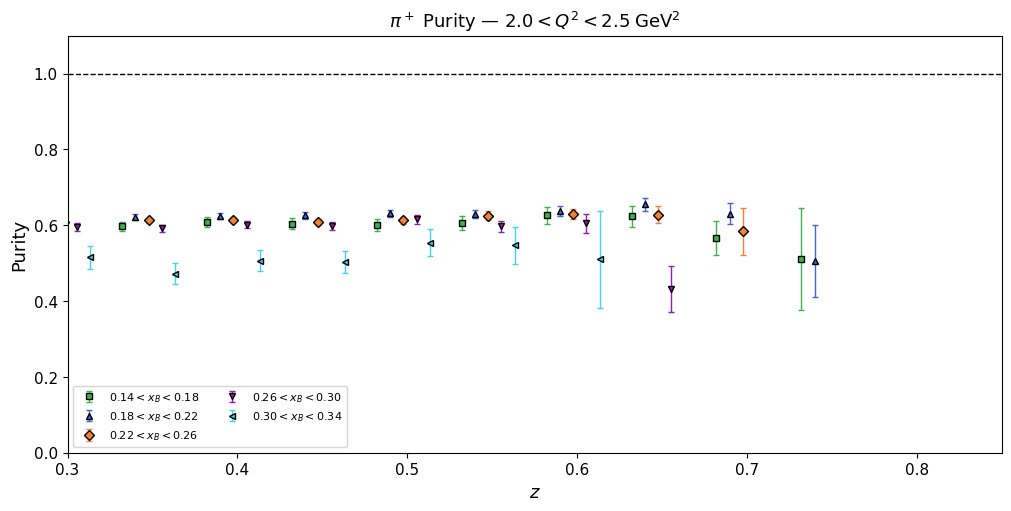

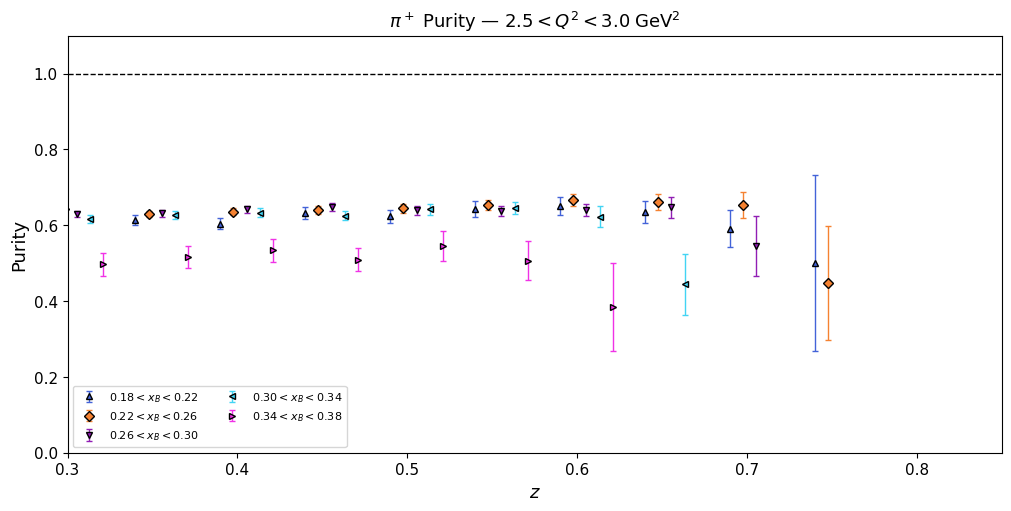

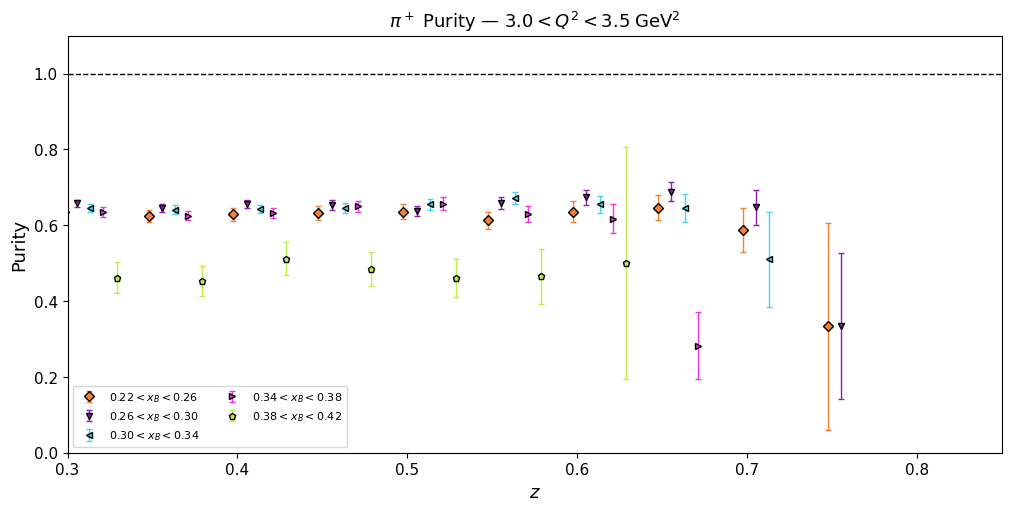

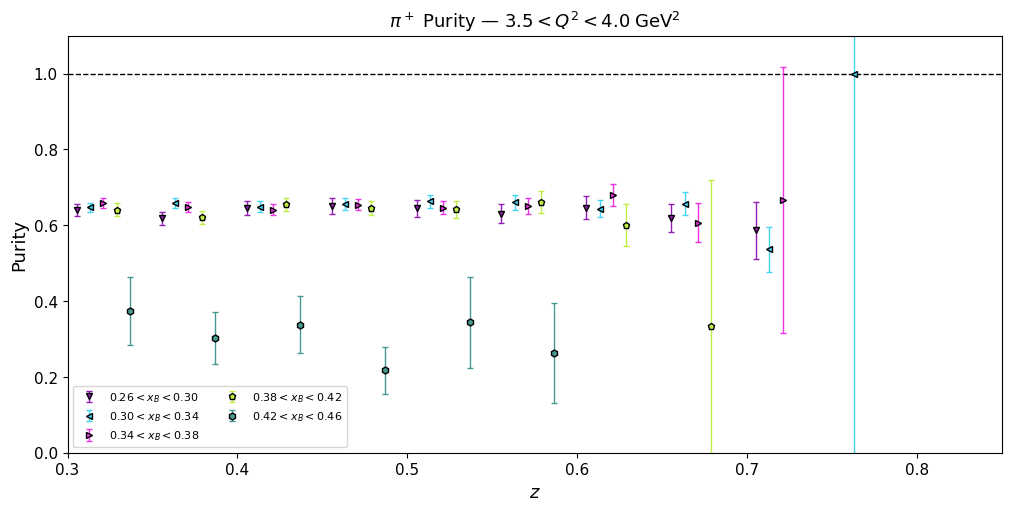

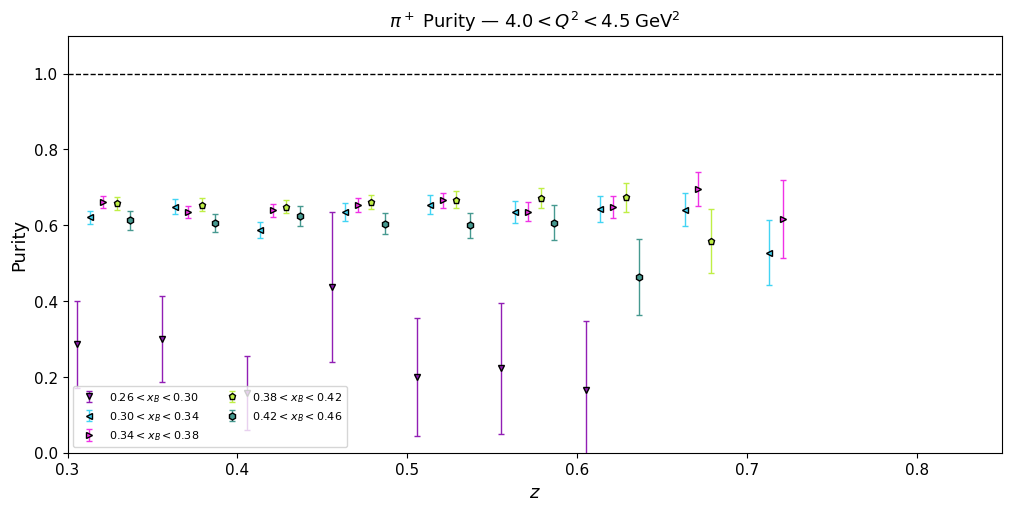

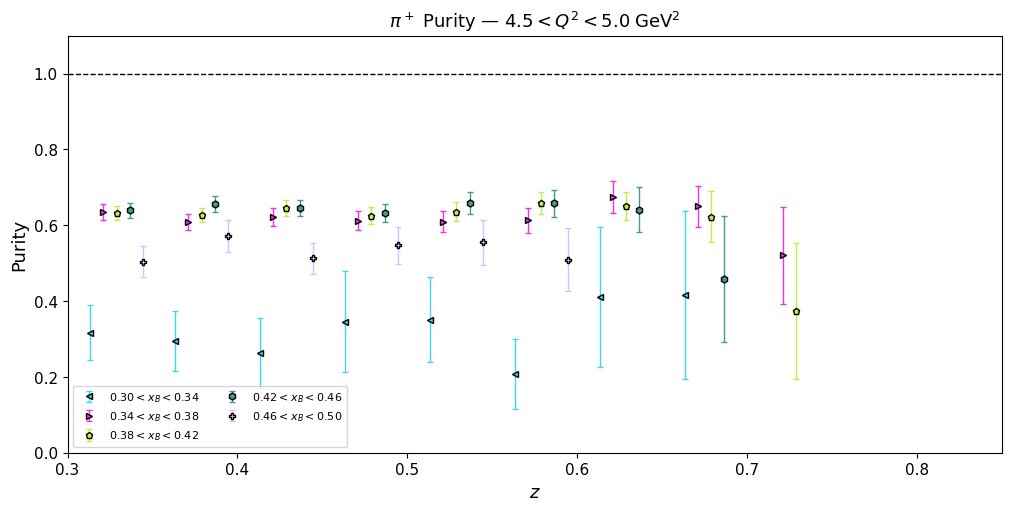

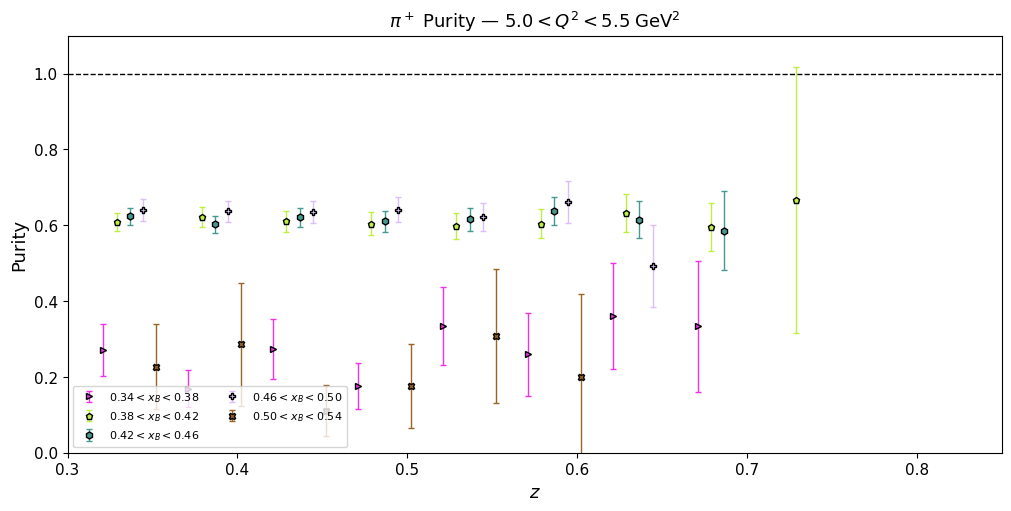

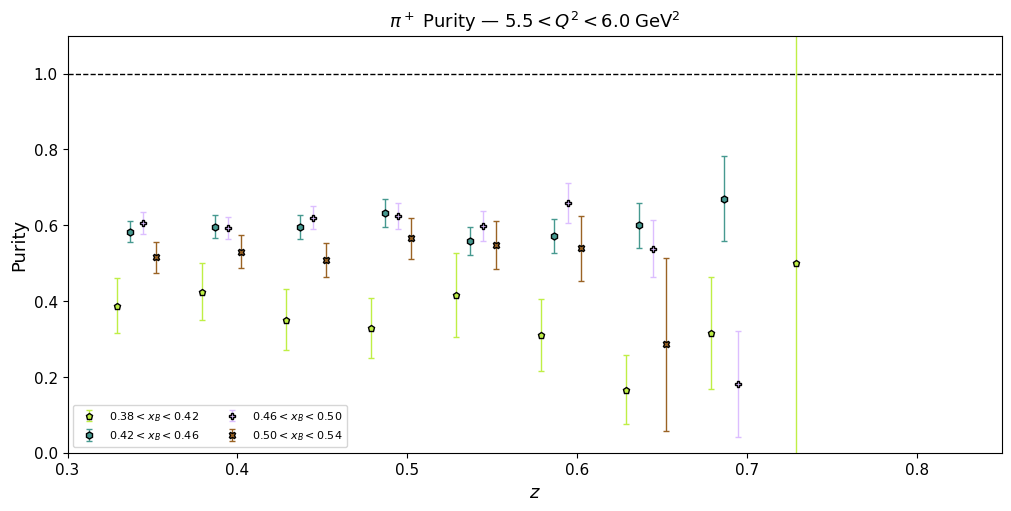

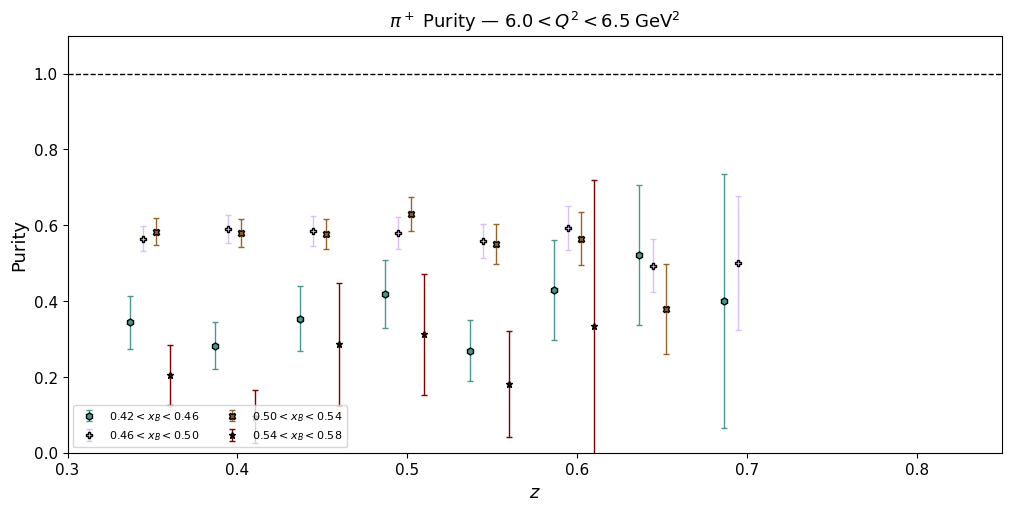

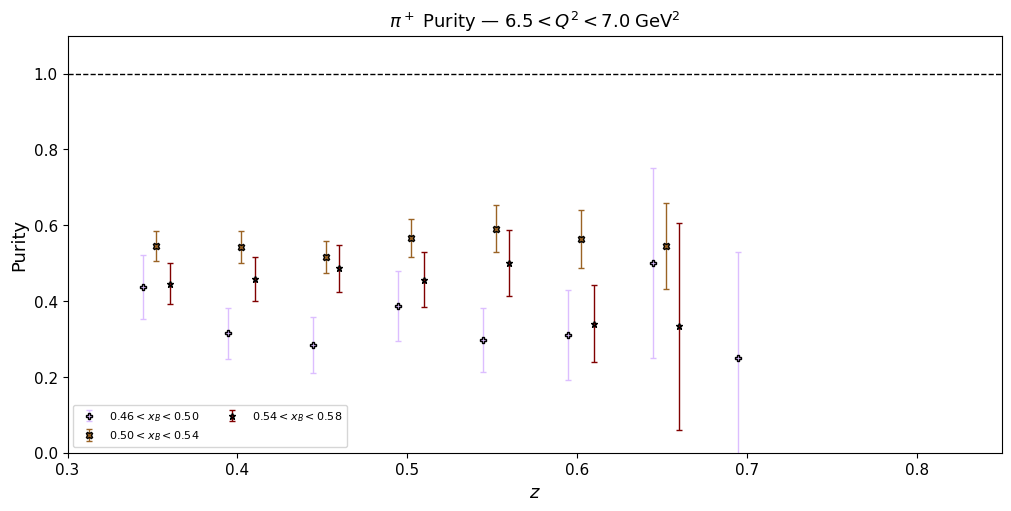

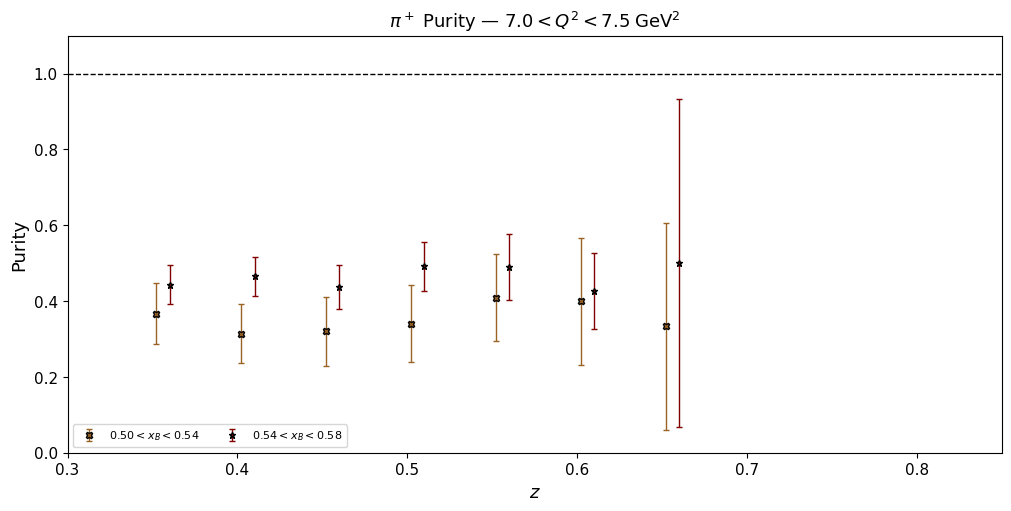

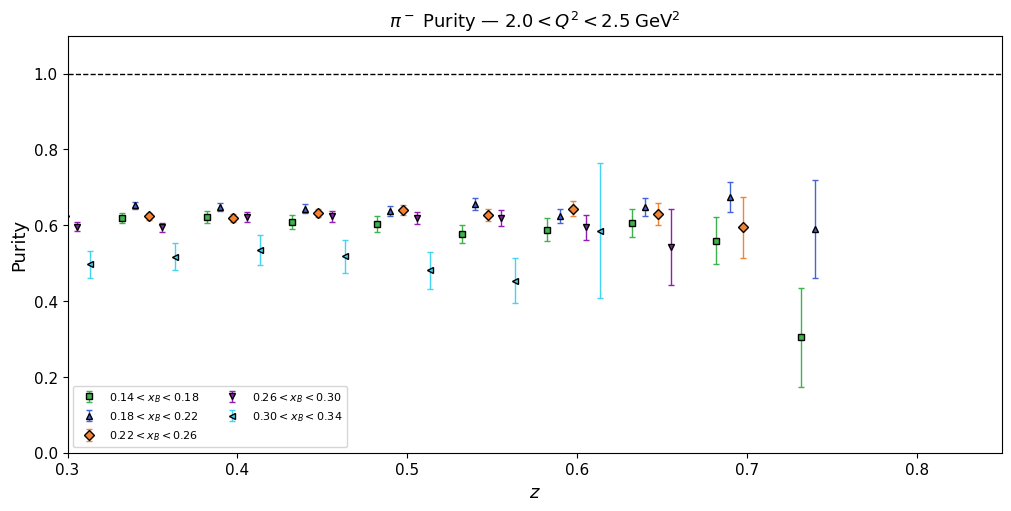

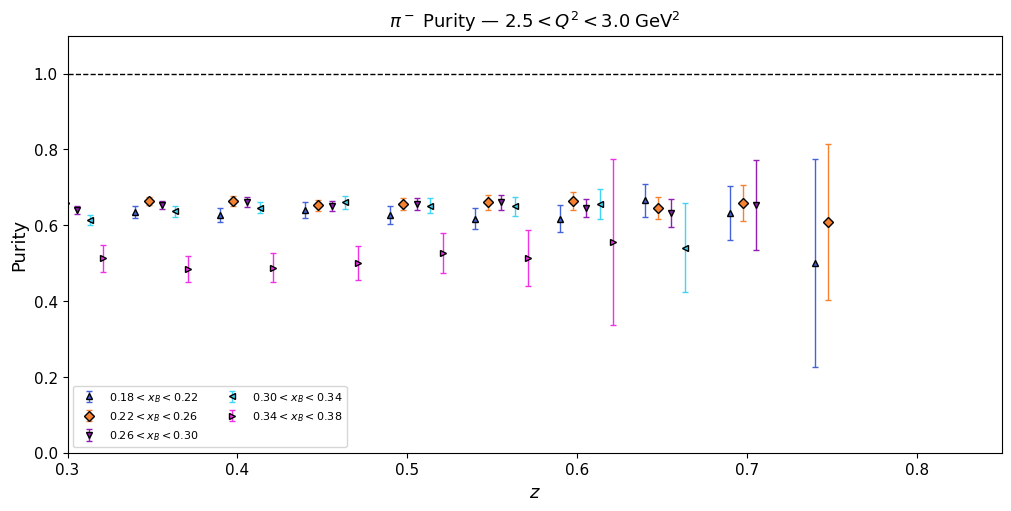

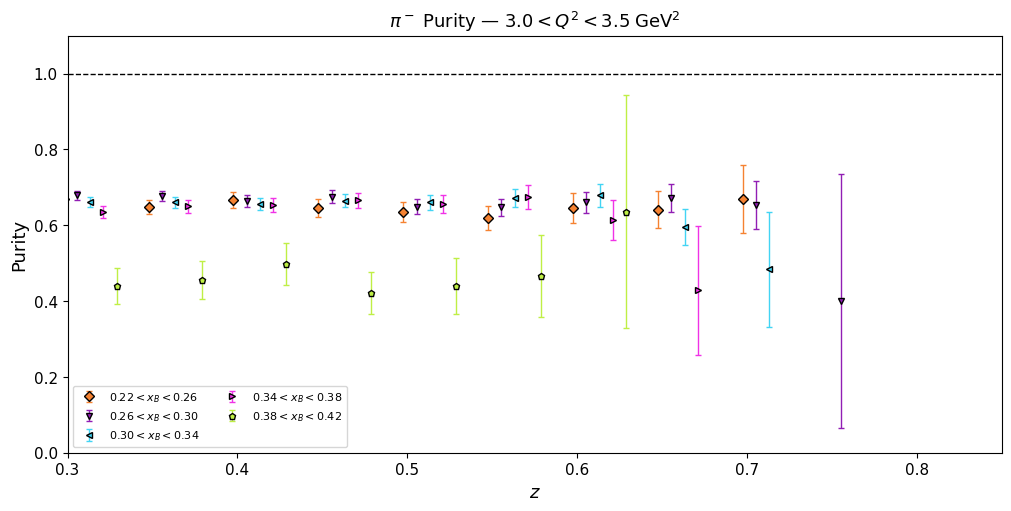

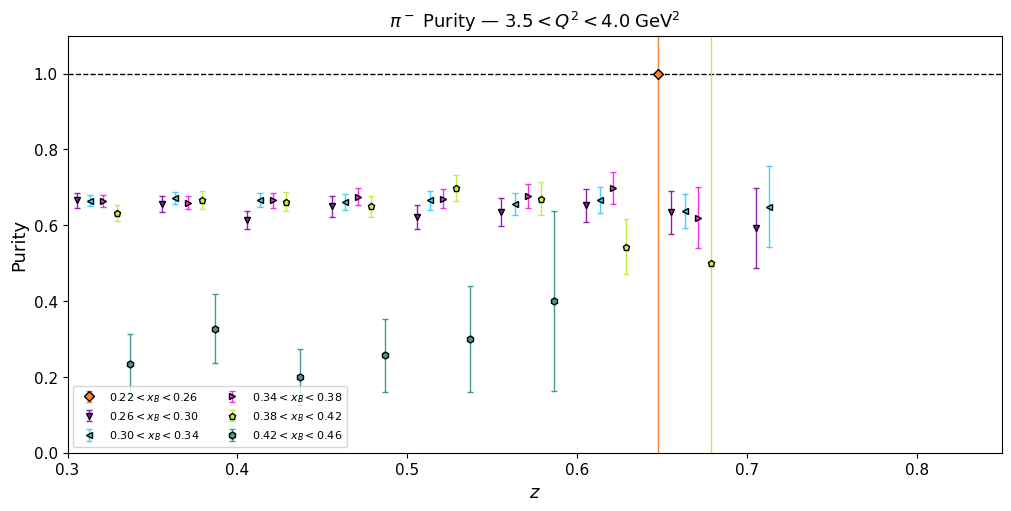

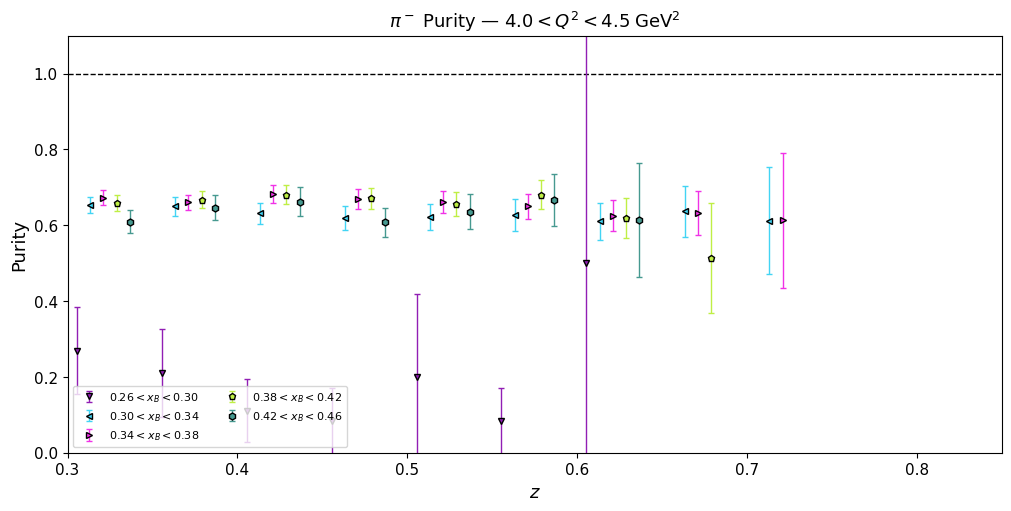

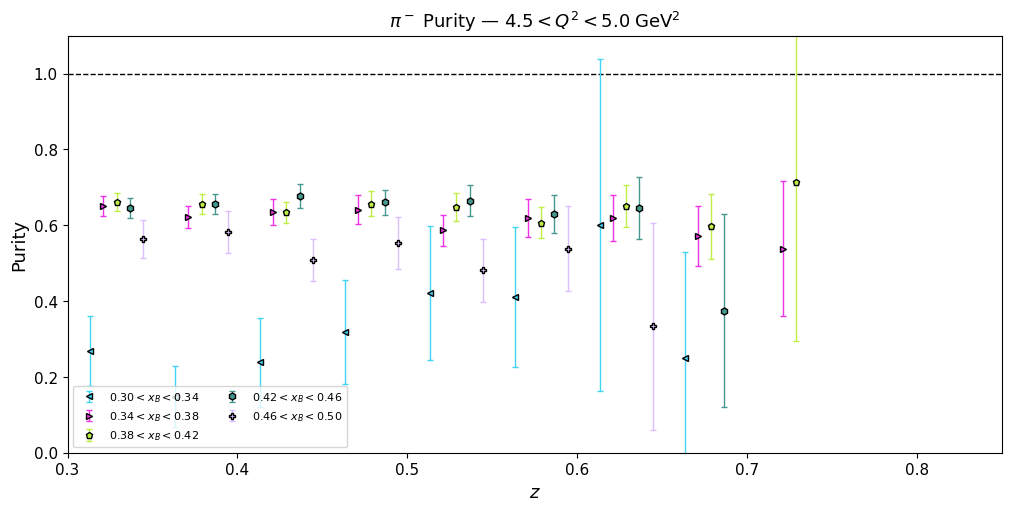

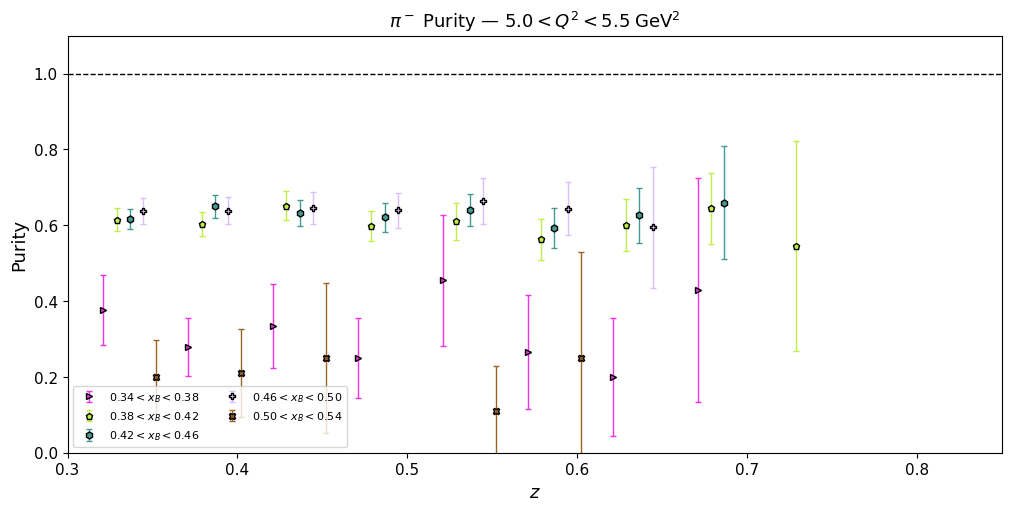

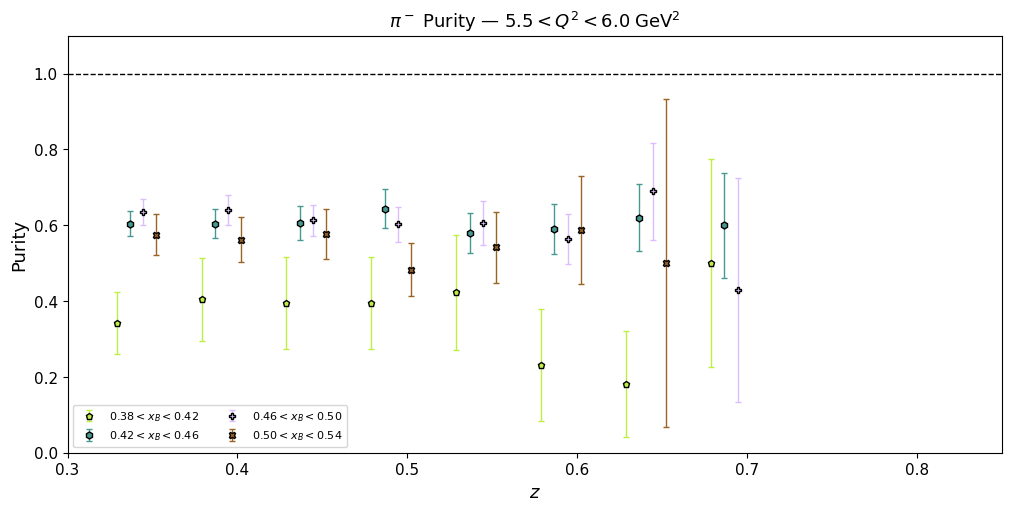

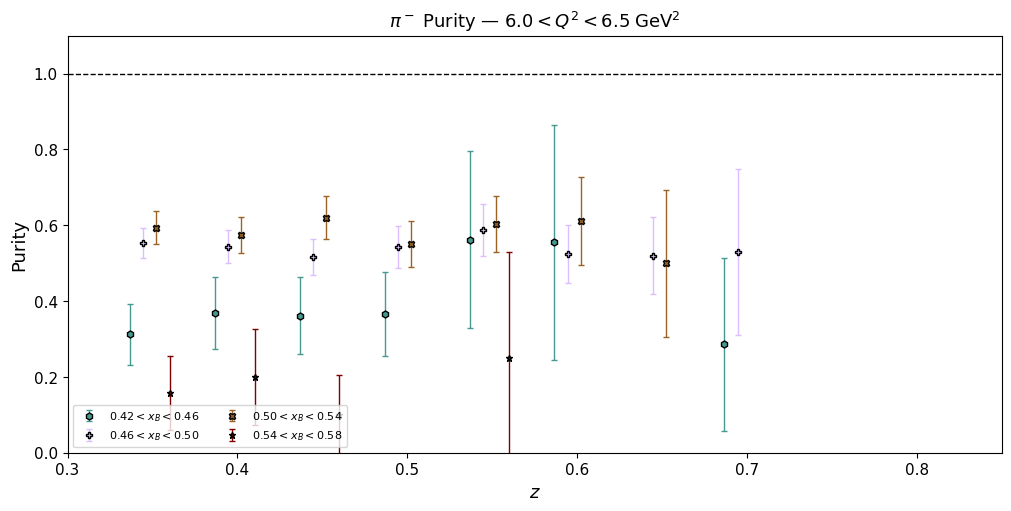

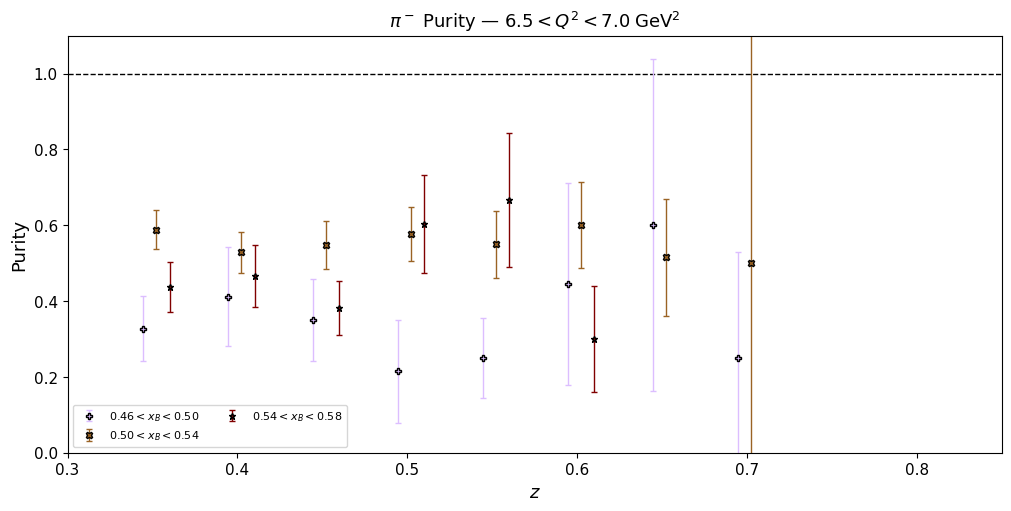

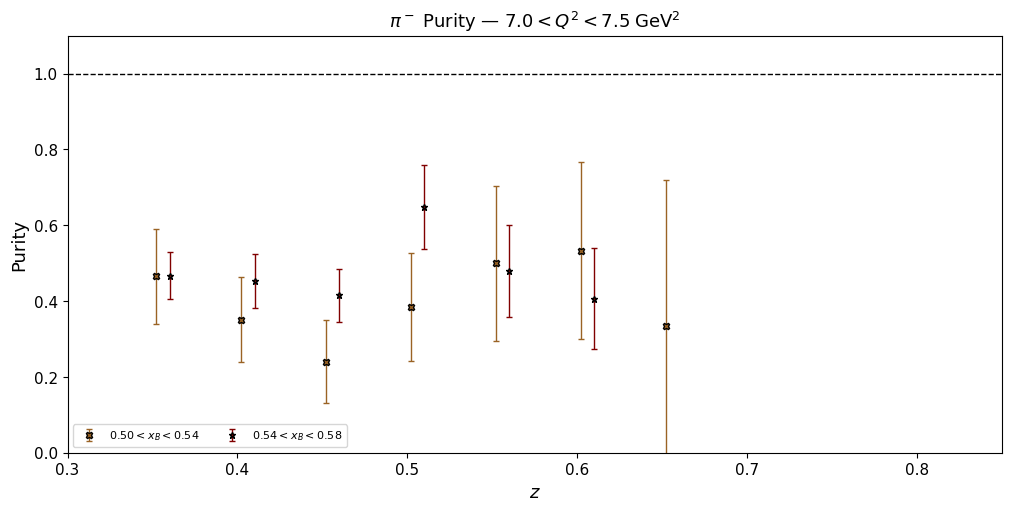

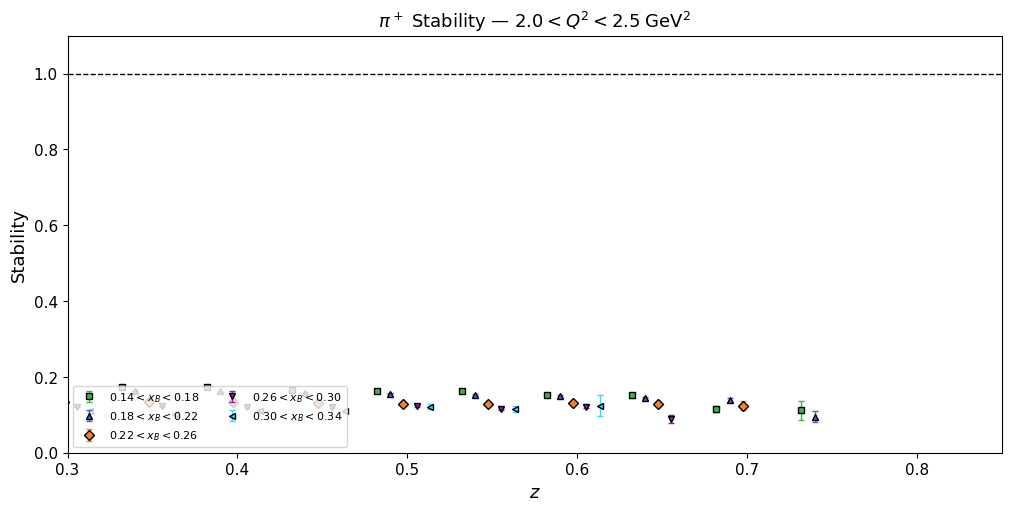

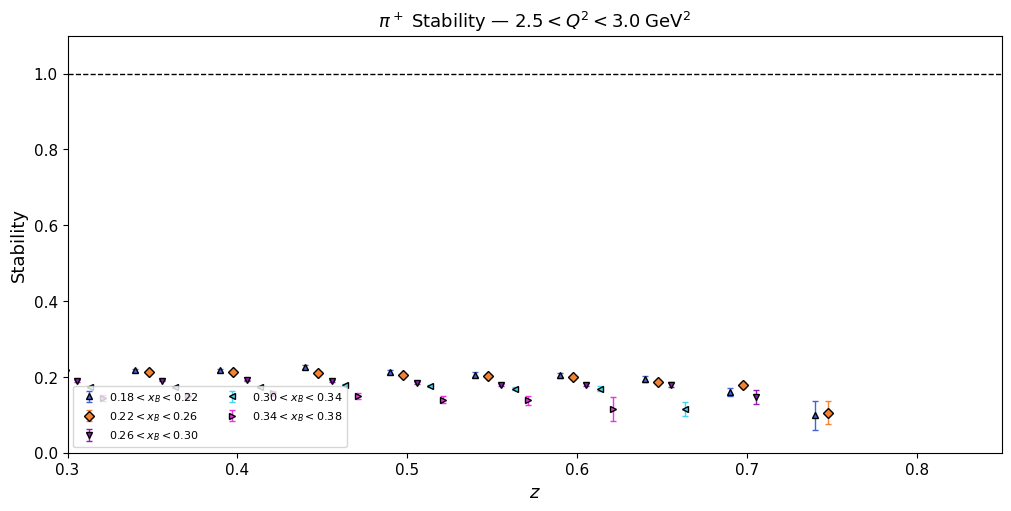

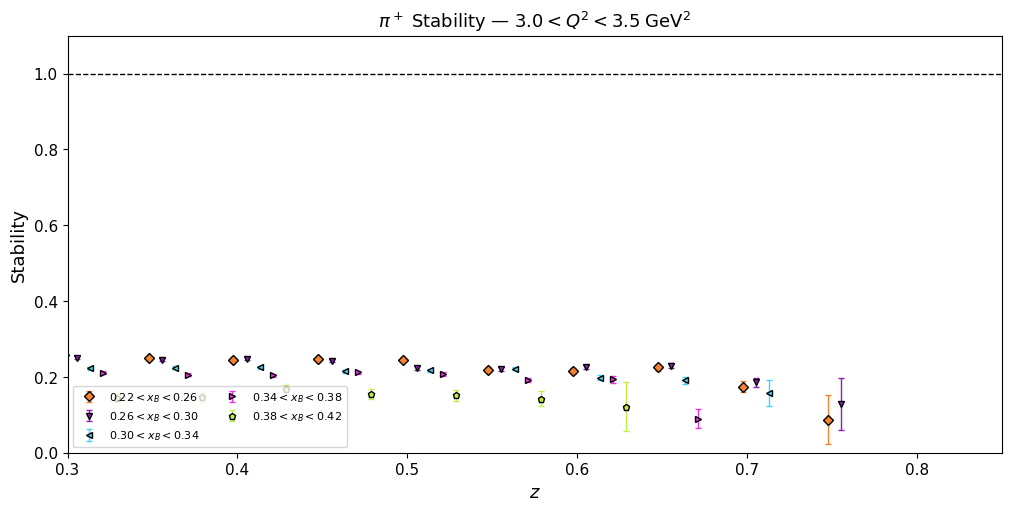

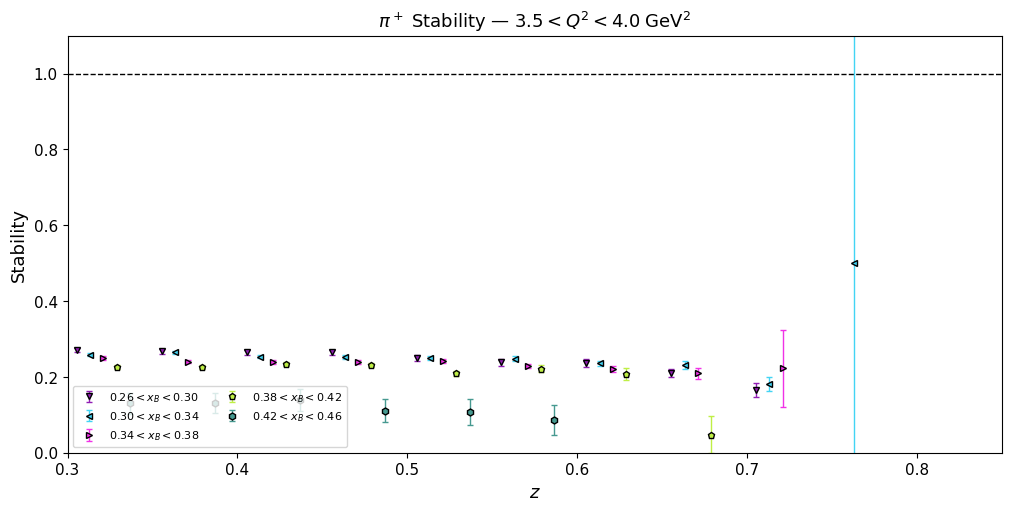

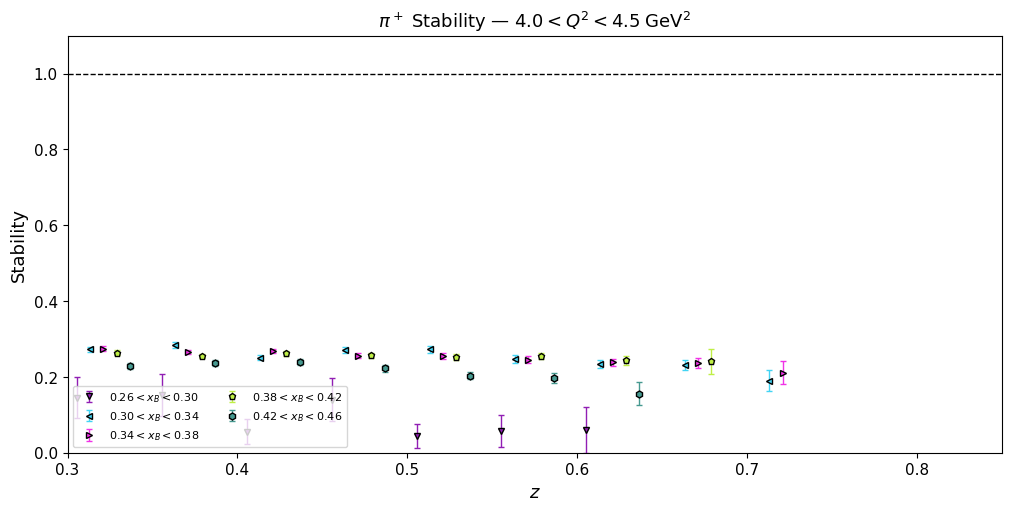

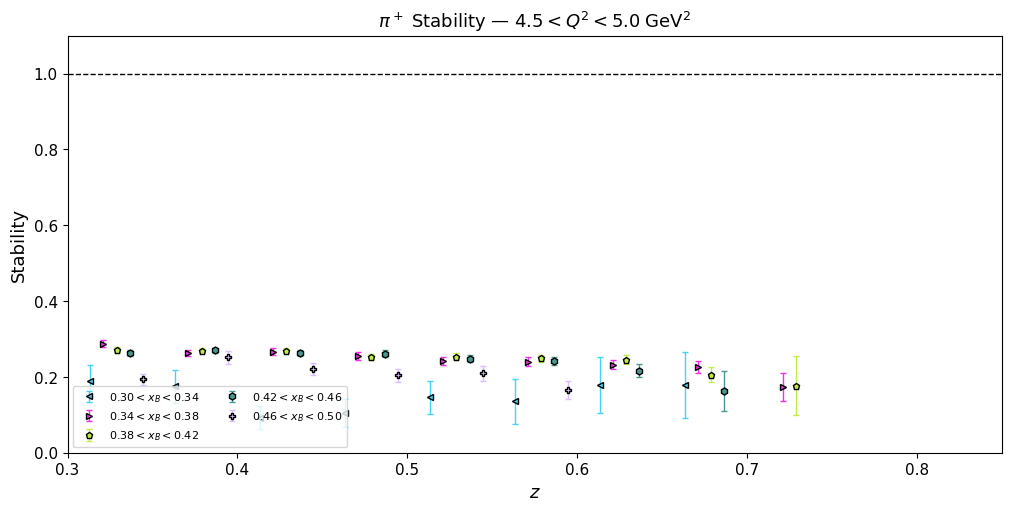

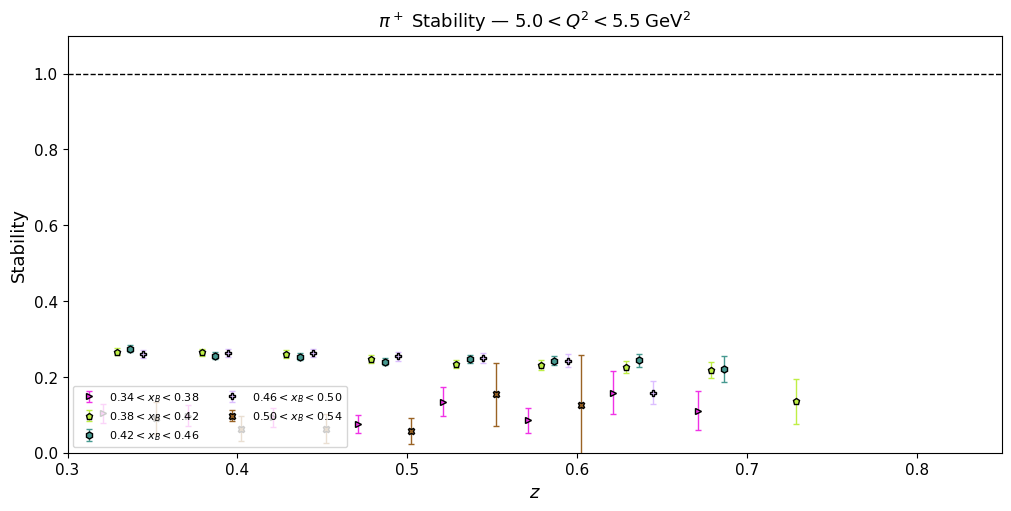

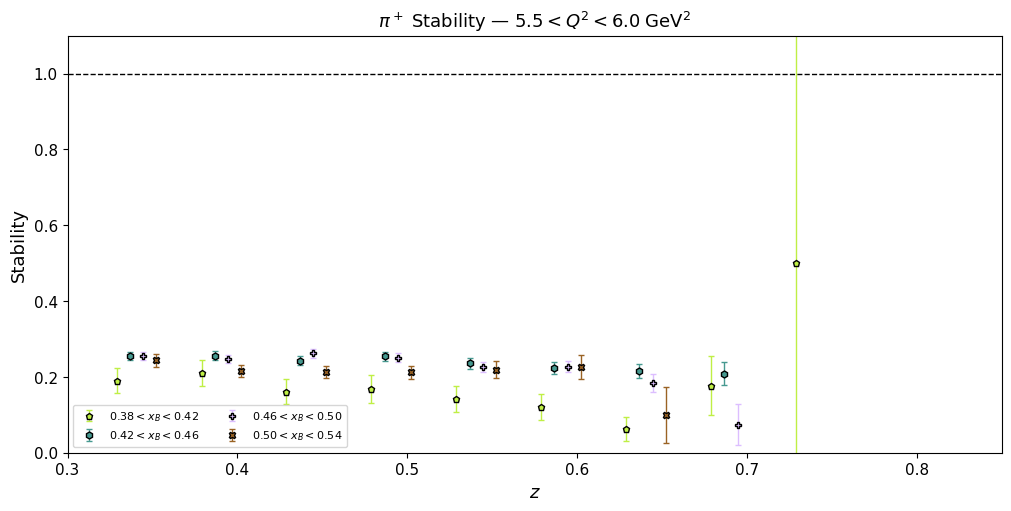

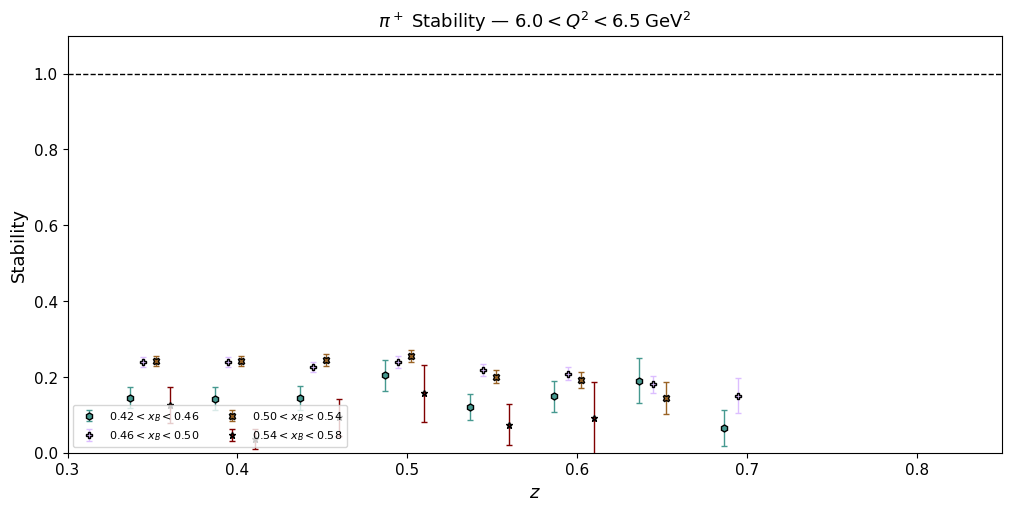

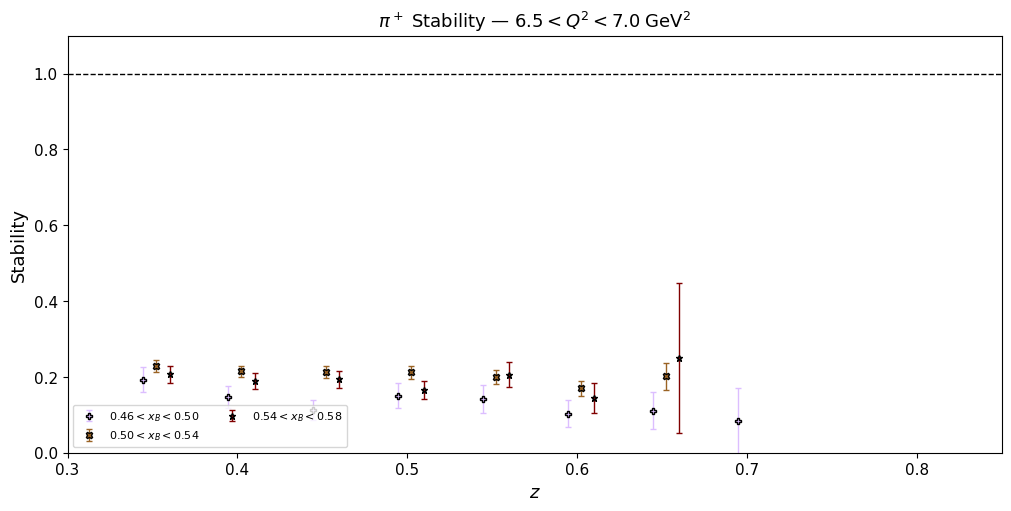

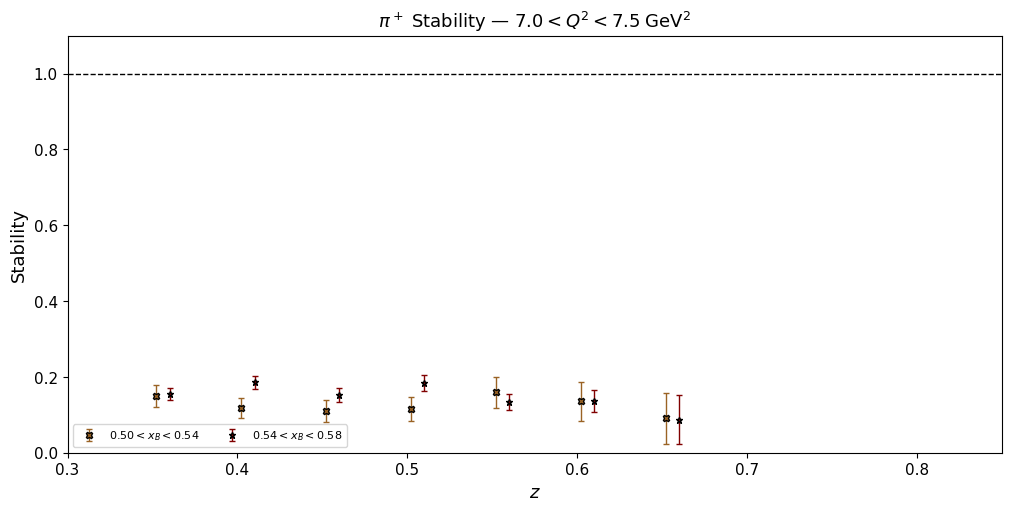

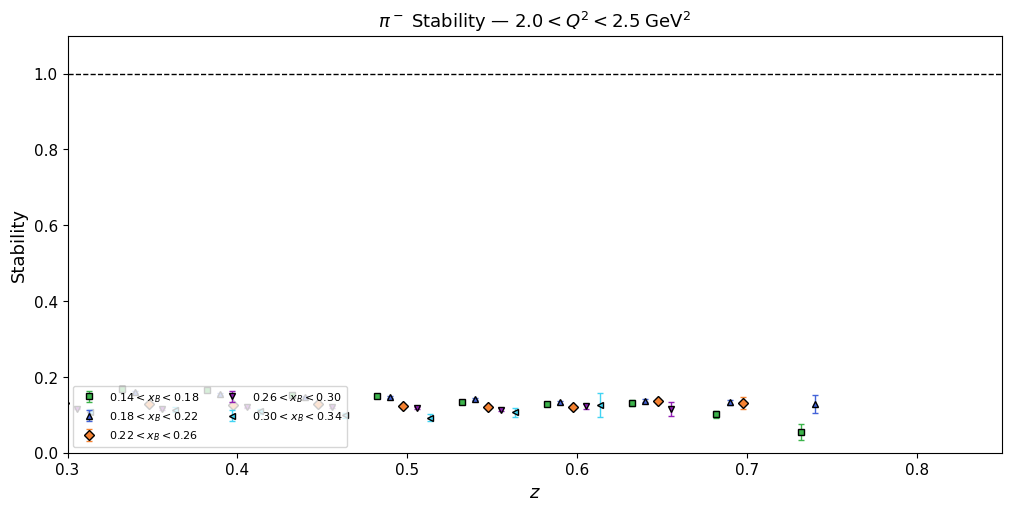

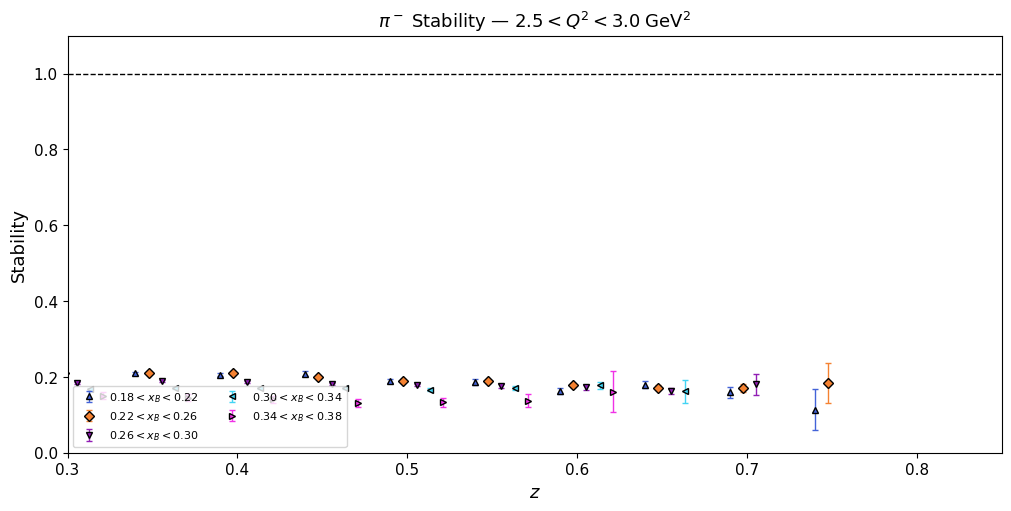

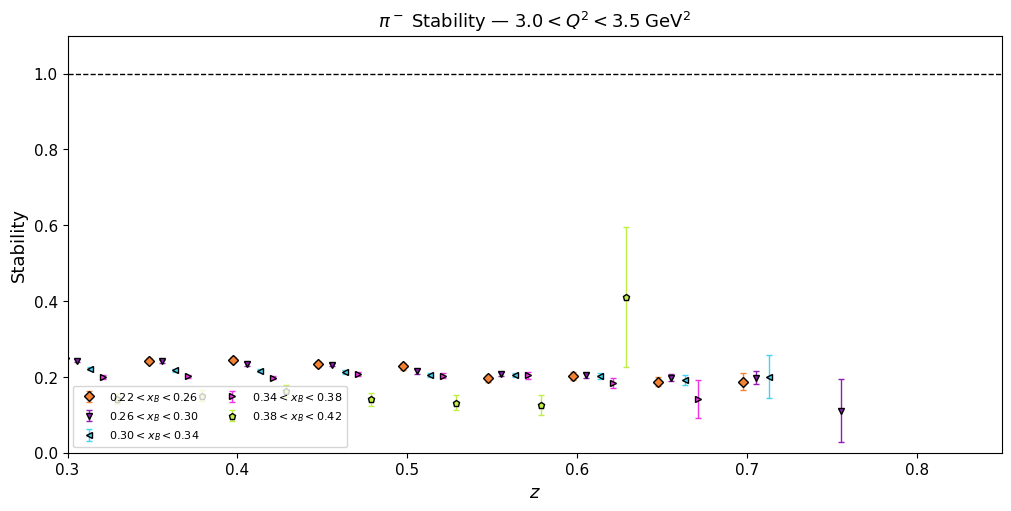

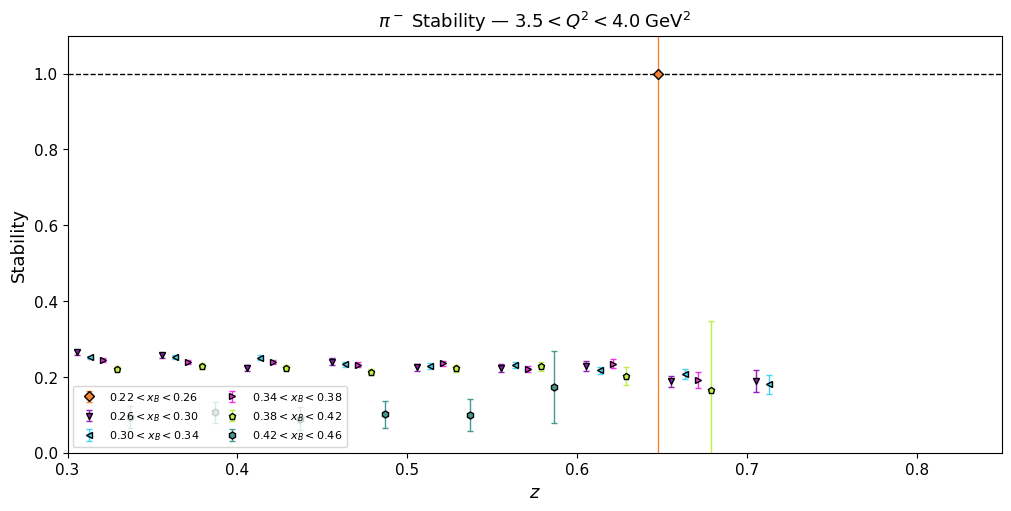

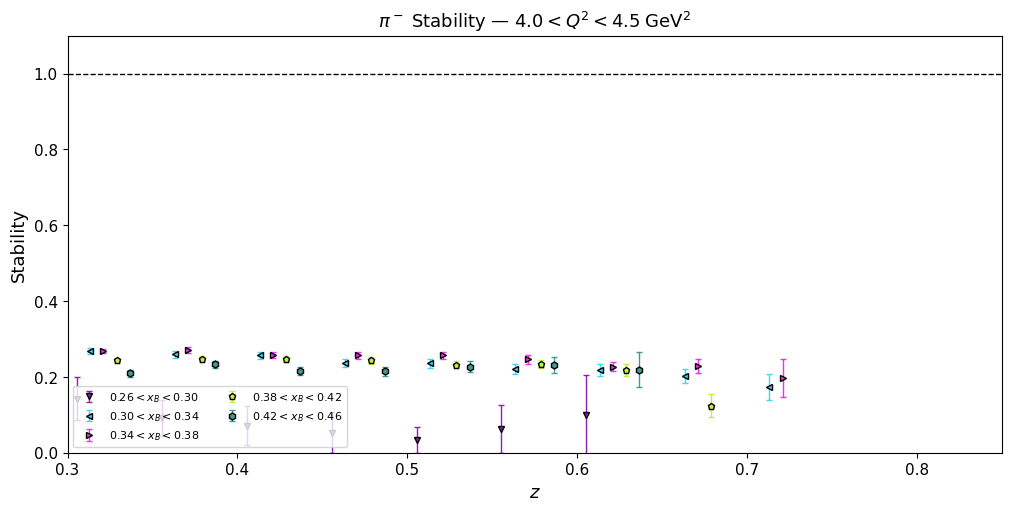

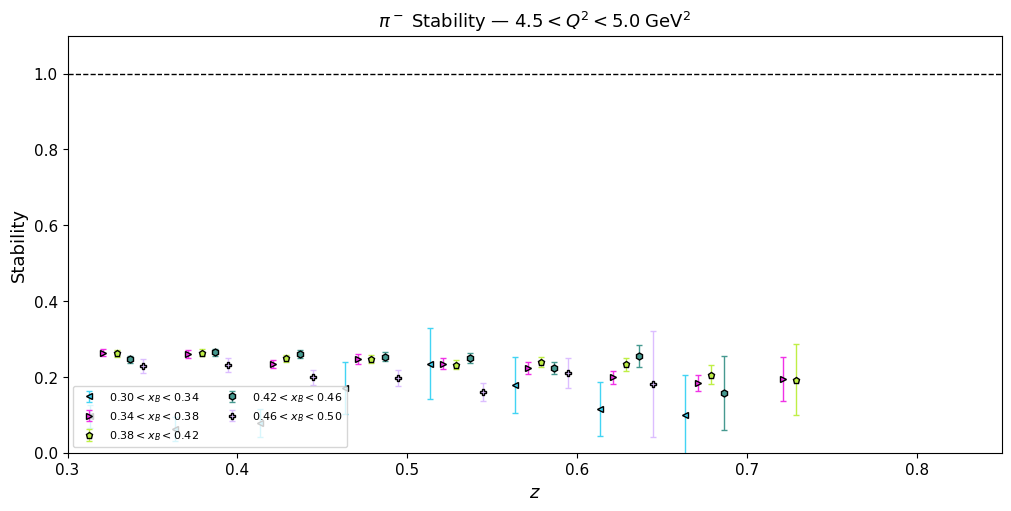

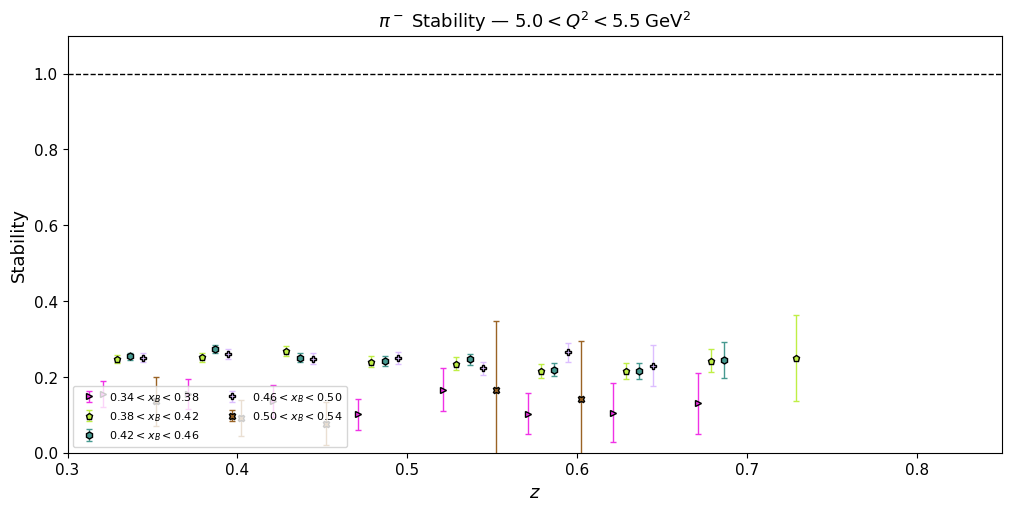

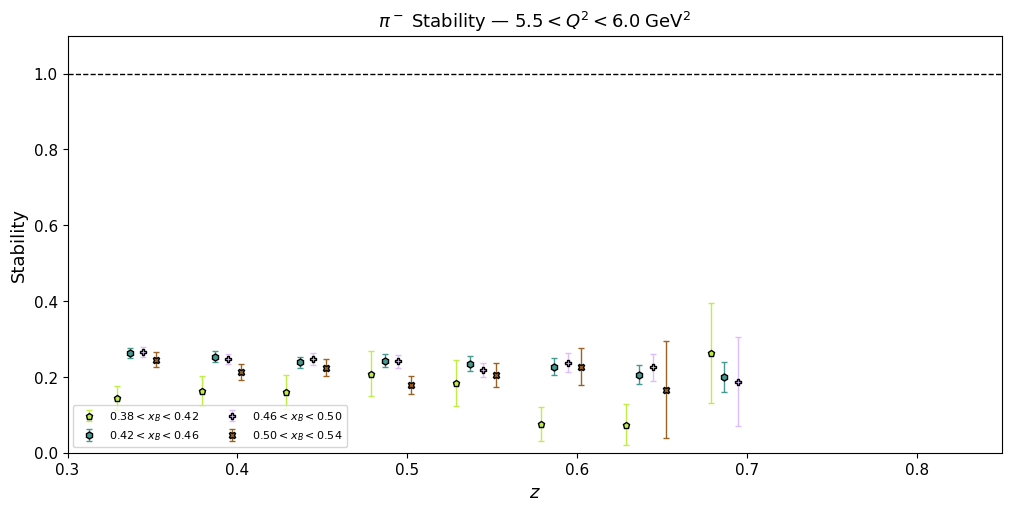

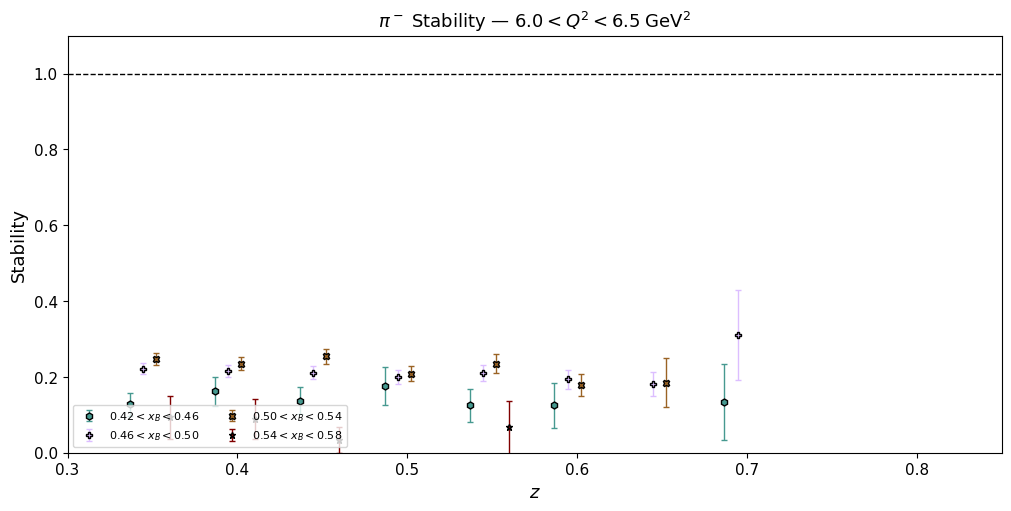

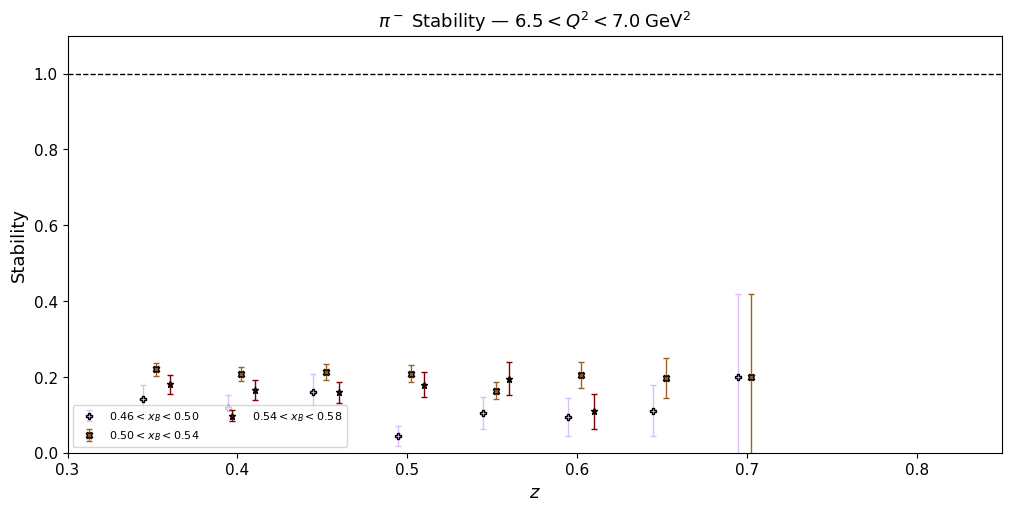

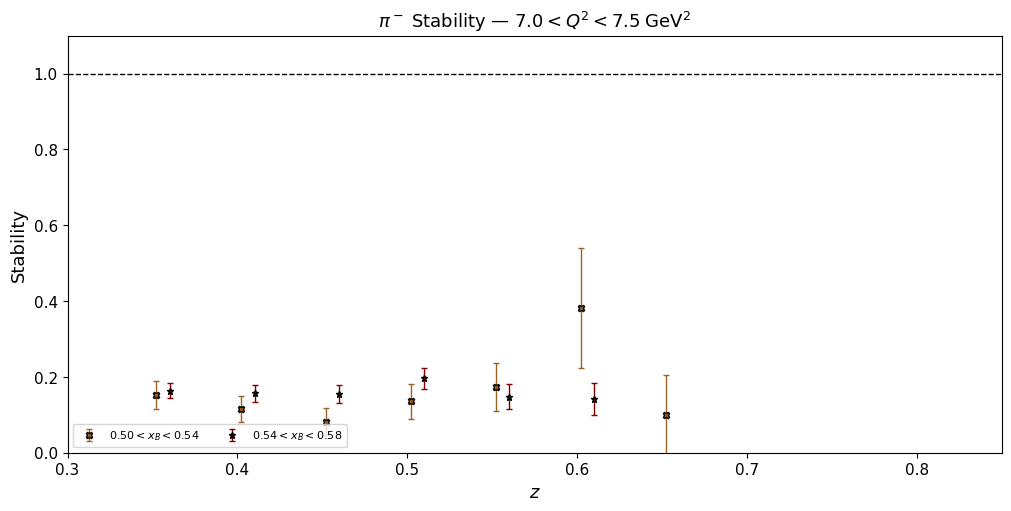

In [31]:
# ── Plot ──────────────────────────────────────────────────────────────────────
if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

# 14 maximally distinct colors
colors_list = [
    '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
    '#42d4f4','#f032e6','#bfef45','#469990','#dcbeff',
    '#9a6324','#800000','#aaffc3','#a9a9a9'
]
markers = ['o','s','^','D','v','<','>','p','h','P','X','*','d','H']

if MODE == 'fixed_x':
    n_outer, n_inner = BINS_XB, BINS_Q2
    outer_label = xb_label
    inner_label = q2_label
    def get_idx(outer, inner):   # returns (xb_idx, q2_idx)
        return outer, inner
else:
    n_outer, n_inner = BINS_Q2, BINS_XB
    outer_label = q2_label
    inner_label = xb_label
    def get_idx(outer, inner):
        return inner, outer

z_span  = z_centers[-1] - z_centers[0] if len(z_centers) > 1 else 0.5
offsets = np.linspace(-(n_inner-1)/2, (n_inner-1)/2, n_inner) * z_span * 0.012

# Which (qty, charge) combinations to plot
panels = []
if PLOT_PURITY:
    if PLOT_PIP: panels.append(('Purity',    'p', r'$\pi^+$ Purity',    'hPurity_p'))
    if PLOT_PIM: panels.append(('Purity',    'm', r'$\pi^-$ Purity',    'hPurity_m'))
if PLOT_STABILITY:
    if PLOT_PIP: panels.append(('Stability', 'p', r'$\pi^+$ Stability', 'hStability_p'))
    if PLOT_PIM: panels.append(('Stability', 'm', r'$\pi^-$ Stability', 'hStability_m'))

for qty_name, charge, panel_title, hist_key in panels:
    if hist_key not in data:
        print(f"Skipping {hist_key} (not loaded)")
        continue

    vals, errs, ax_xb, ax_q2, ax_z = data[hist_key]

    for outer in range(n_outer):
        fig, ax = plt.subplots(figsize=(10, 5), layout='constrained')
        ax.axhline(1, color='black', linestyle='--', lw=1, zorder=0)

        has_data = False
        for inner in range(n_inner):
            xb_i, q2_i = get_idx(outer, inner)

            if xb_i >= vals.shape[0] or q2_i >= vals.shape[1]:
                continue

            v = vals[xb_i, q2_i, :]   # shape (nZ,)
            e = errs[xb_i, q2_i, :]

            mask = np.isfinite(v) & (v > 0)
            if not mask.any():
                continue

            z_plot = z_centers + offsets[inner]
            color  = colors_list[inner % len(colors_list)]
            marker = markers[inner % len(markers)]

            ax.errorbar(
                z_plot[mask], v[mask], e[mask],
                marker=marker, color=color, linestyle='',
                capsize=2, lw=1, capthick=1, markersize=5, mec='black',
                label=inner_label(inner)
            )
            has_data = True

        if not has_data:
            plt.close(fig)
            continue

        ax.set_title(f"{panel_title} — {outer_label(outer)}", fontsize=13)
        ax.set_xlabel(r'$z$', fontsize=13)
        ax.set_ylabel(qty_name, fontsize=13)
        ax.set_xlim(0.3, 0.85)
        ax.set_ylim(0, 1.1)
        ax.tick_params(labelsize=11)
        ax.legend(fontsize=8, loc='lower left', ncol=2)

        if OUT_DIR:
            fname = f"{OUT_DIR}/{qty_name}_{charge}_{MODE}_{outer+1}.png"
            #fig.savefig(fname, dpi=150)
            plt.close(fig)
            print(f"Saved {fname}")
        else:
            plt.show()

## Purity vs Stability comparison
One figure per charge, purity and stability overlaid for a single (Q², xB) bin.

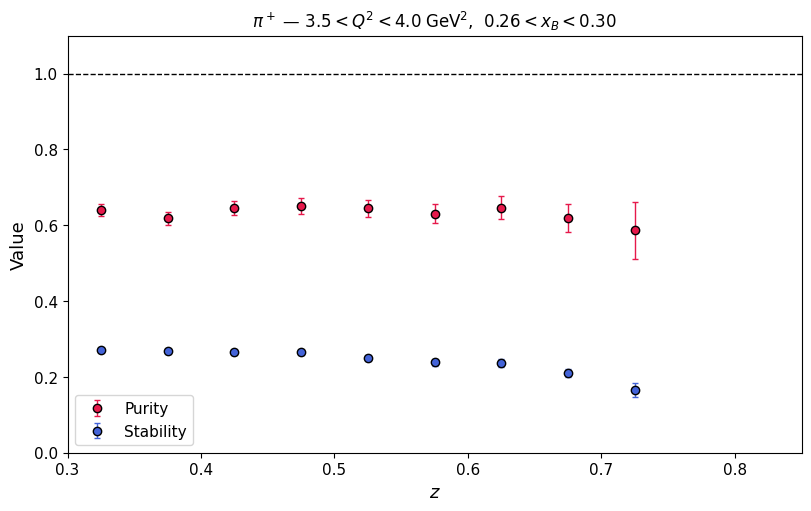

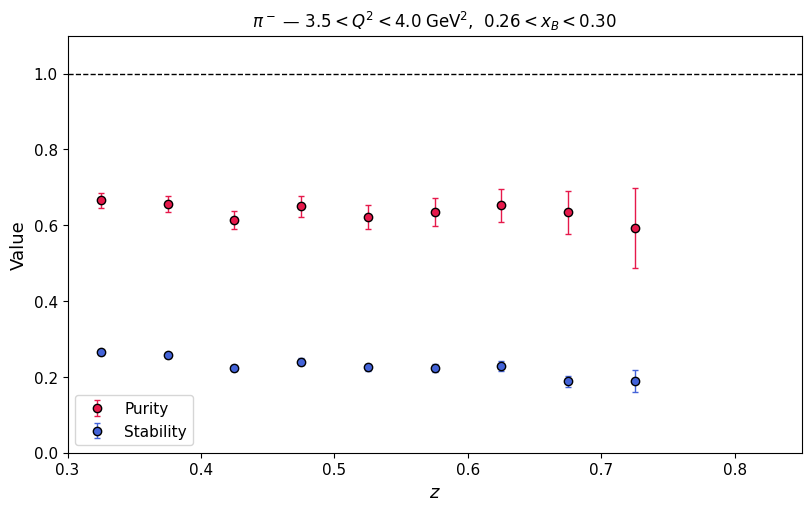

In [32]:
# 0-based indices to inspect
Q2_INSPECT = 3
XB_INSPECT = 4

for charge, label in [('p', r'$\pi^+$'), ('m', r'$\pi^-$')]:
    pk = f'hPurity_{charge}'
    sk = f'hStability_{charge}'
    if pk not in data or sk not in data:
        continue

    pv, pe = data[pk][0][XB_INSPECT, Q2_INSPECT, :], data[pk][1][XB_INSPECT, Q2_INSPECT, :]
    sv, se = data[sk][0][XB_INSPECT, Q2_INSPECT, :], data[sk][1][XB_INSPECT, Q2_INSPECT, :]

    fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
    ax.axhline(1, color='black', linestyle='--', lw=1)

    for v, e, color, name in [
        (pv, pe, '#e6194b', 'Purity'),
        (sv, se, '#4363d8', 'Stability')
    ]:
        mask = np.isfinite(v) & (v > 0)
        ax.errorbar(z_centers[mask], v[mask], e[mask],
                    marker='o', color=color, linestyle='',
                    capsize=2, lw=1, capthick=1, markersize=6, mec='black',
                    label=name)

    ax.set_title(f"{label} — {q2_label(Q2_INSPECT)},  {xb_label(XB_INSPECT)}", fontsize=12)
    ax.set_xlabel(r'$z$', fontsize=13)
    ax.set_ylabel('Value', fontsize=13)
    ax.set_xlim(0.3, 0.85)
    ax.set_ylim(0, 1.1)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=11)
    plt.show()

## 2D summary: mean purity / stability vs (xB, Q²)
Colormaps showing the z-averaged purity and stability across the kinematic plane.

/var/folders/4d/9x90517x6q3cc4_sz1jrqlj00000gn/T/ipykernel_50129/222193651.py:17: RuntimeWarning: Mean of empty slice
  mean_2d = np.nanmean(np.where(v > 0, v, np.nan), axis=2)  # (nXb, nQ2)


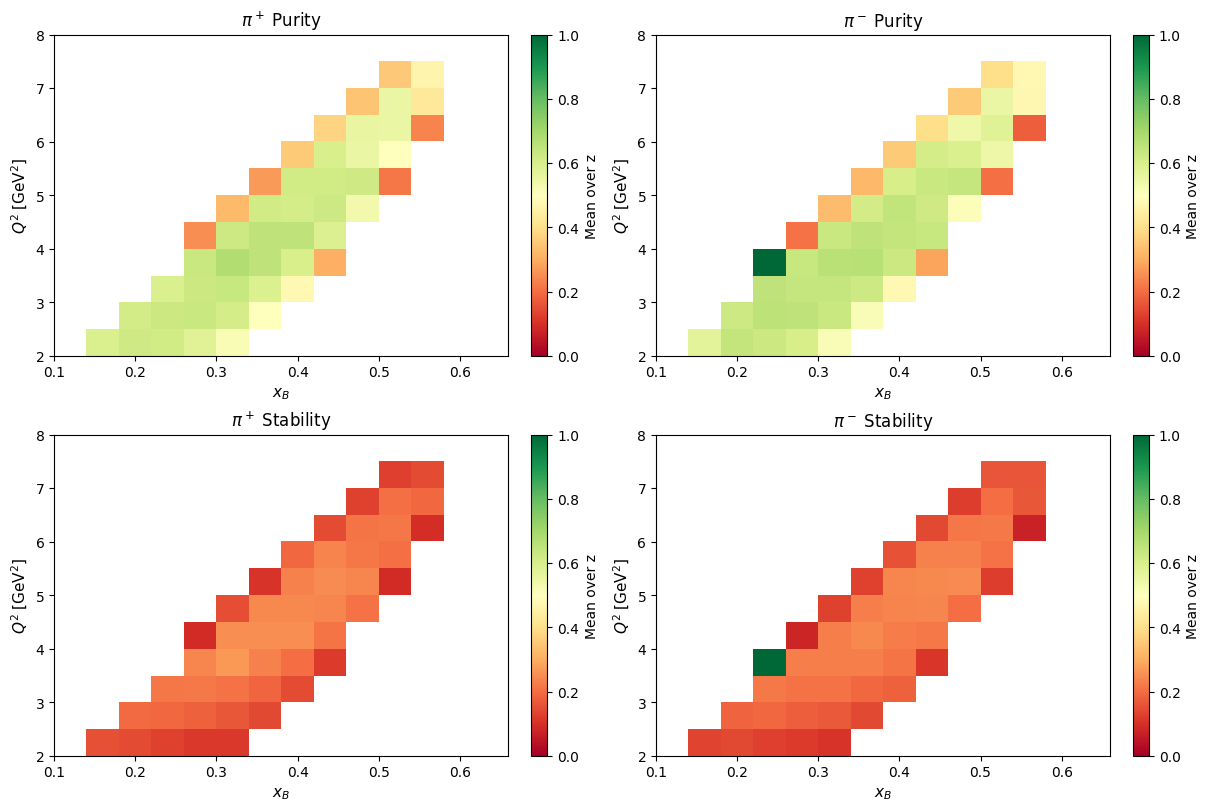

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
titles = [
    (r'$\pi^+$ Purity',    'hPurity_p'),
    (r'$\pi^-$ Purity',    'hPurity_m'),
    (r'$\pi^+$ Stability', 'hStability_p'),
    (r'$\pi^-$ Stability', 'hStability_m'),
]

for ax, (title, key) in zip(axes.flat, titles):
    if key not in data:
        ax.set_visible(False)
        continue

    v = data[key][0]  # shape (nXb, nQ2, nZ)
    # Mean over z-bins (ignoring zeros)
    with np.errstate(invalid='ignore'):
        mean_2d = np.nanmean(np.where(v > 0, v, np.nan), axis=2)  # (nXb, nQ2)

    im = ax.imshow(
        mean_2d.T,  # transpose so Q2 is y-axis
        origin='lower', aspect='auto',
        extent=[XB_MIN, XB_MAX, Q2_MIN, Q2_MAX],
        vmin=0, vmax=1, cmap='RdYlGn'
    )
    fig.colorbar(im, ax=ax, label='Mean over z')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r'$x_B$', fontsize=11)
    ax.set_ylabel(r'$Q^2\;[\mathrm{GeV}^2]$', fontsize=11)
    ax.tick_params(labelsize=10)

plt.show()